# Pipeline for the anomaly detection on the SKAB using LSTM-Autoencoder

Details regarding the SKAB one can find in the [SKAB repository](https://github.com/waico/SKAB).

In [1]:
# libraries importing
import sys
import warnings

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

sys.path.append("..")
from core.LSTM_VAE_pytorch import LSTM_VAE
from core.metrics import chp_score
from core.utils import create_sequences, load_preprocess_skab, plot_results

warnings.filterwarnings("ignore", category=UserWarning)

## Data

In [2]:
Xy_traintest_list = load_preprocess_skab()

## Method

### Method initialization

In [3]:
# hyperparameters selection
EPOCHS = 40
BATCH_SIZE = 32
N_STEPS = 10
Q = 0.99
PARAM = [64, 1e-3, BATCH_SIZE, EPOCHS]  # [hidden_dim, lr, batch_size, epochs]

In [4]:
model = LSTM_VAE(PARAM)

### Method fitting and applying

In [5]:
# inference
predicted_outlier, predicted_cp = [], []
true_outlier, true_cp = [], []
all_scores = []
for X_train, X_test, y_train, y_test in Xy_traintest_list:
    # scaler init and fitting
    StSc = StandardScaler()
    StSc.fit(X_train)

    # convert into input/output
    X = create_sequences(StSc.transform(X_train), N_STEPS)

    # model fitting
    # history, model = arch(X)
    model.fit(X)

    # results predicting
    residuals = pd.Series(
        np.sum(np.mean(np.abs(X - model.predict(X)), axis=1), axis=1)
    )
    UCL = residuals.quantile(Q) * 3 / 2

    # results predicting
    X = create_sequences(StSc.transform(X_test), N_STEPS)
    cnn_residuals = pd.Series(
        np.sum(np.mean(np.abs(X - model.predict(X)), axis=1), axis=1)
    )
    all_scores.append(cnn_residuals)

    # data i is an anomaly if samples [(i - timesteps + 1) to (i)] are anomalies
    anomalous_data = cnn_residuals > UCL
    anomalous_data_indices = []
    for data_idx in range(N_STEPS - 1, len(X) - N_STEPS + 1):
        if np.all(anomalous_data[data_idx - N_STEPS + 1 : data_idx]):
            anomalous_data_indices.append(data_idx)

    prediction = pd.Series(data=0, index=X_test.index)
    prediction.iloc[anomalous_data_indices] = 1

    # predicted outliers saving
    predicted_outlier.append(prediction)

    # predicted CPs saving
    prediction_cp = abs(prediction.diff())
    prediction_cp.iloc[0] = prediction.iloc[0]
    predicted_cp.append(prediction_cp)

    true_outlier.append(y_test["anomaly"].iloc[N_STEPS - 1:len(cnn_residuals) + N_STEPS - 1])
    true_cp.append(y_test["changepoint"])

### Results visualization

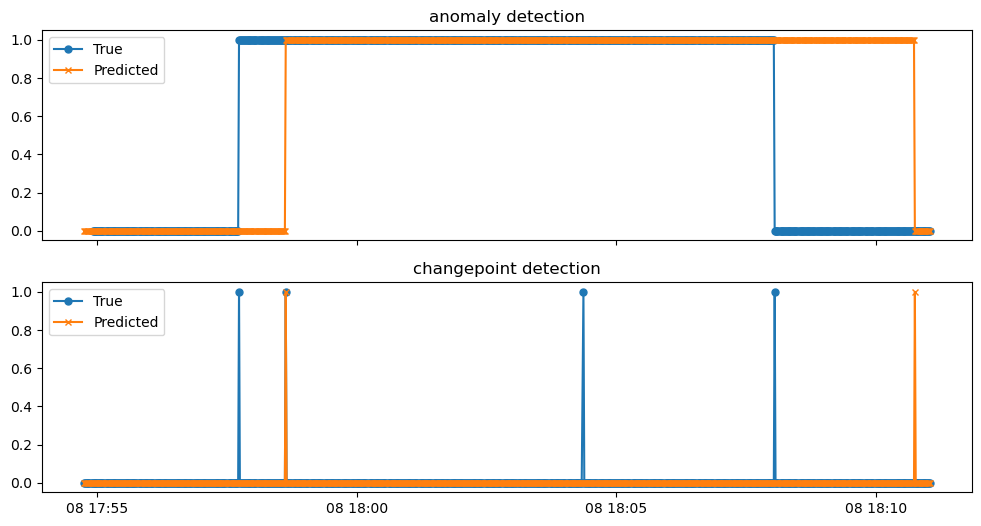

In [6]:
# [donotremove]
plot_results(
    (true_outlier[1], predicted_outlier[1]),
    (true_cp[1], predicted_cp[1]),
)

## Evaluation (metrics calculation)

In [7]:
import pickle

pickle.dump(
    predicted_outlier,
    open(f"../results/results-{model.__class__.__name__}.pkl", "wb"),
)

Zapisano: images/lc_lstm_vae.png


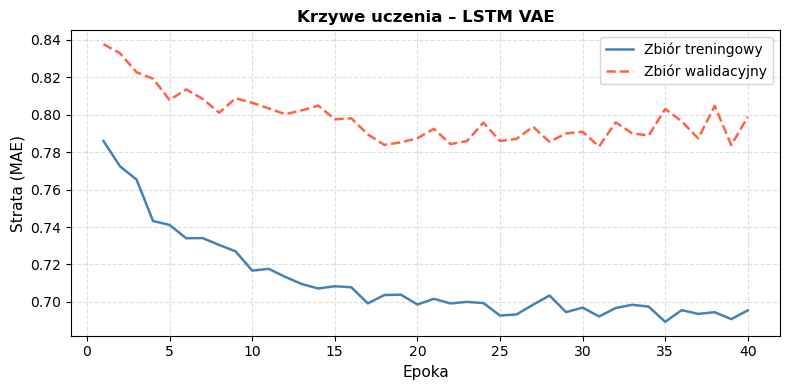

In [8]:
import os
from core.plot_learning_curve import plot_learning_curve

os.makedirs("images", exist_ok=True)
plot_learning_curve(
    model,
    'LSTM VAE',
    save_path='images/lc_lstm_vae.png'
)

In [9]:
print(len(all_scores[0]), len(true_outlier[0]))

336 336


Zapisano ROC: images/roc_lstm_vae.png


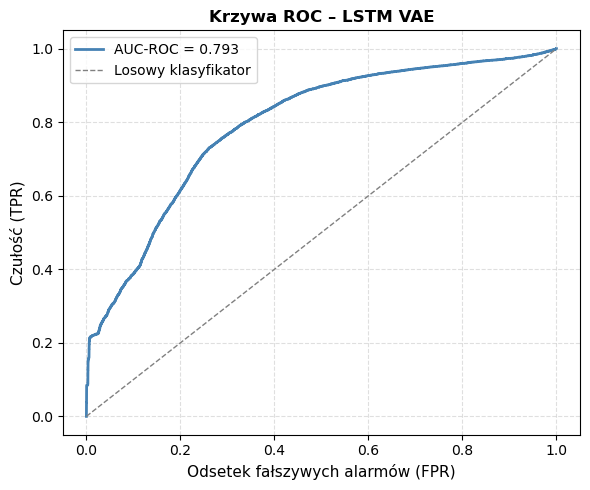

Zapisano PR: images/pr_lstm_vae.png


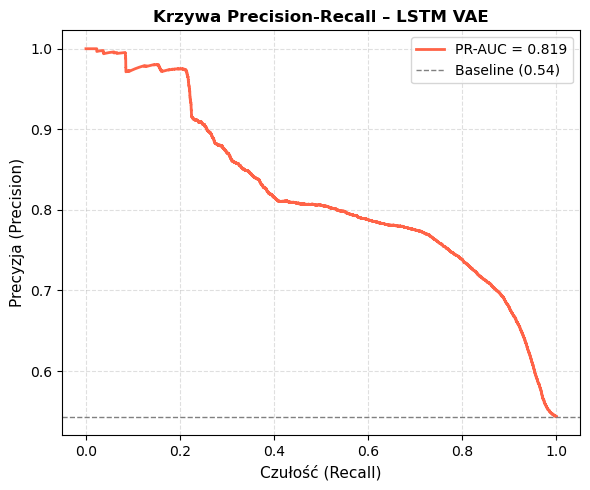


Model:    LSTM VAE
AUC-ROC:  0.7933
PR-AUC:   0.8188
MCC:      0.4676  (próg optymalny = 10.9180)

{'auc_roc': 0.7933, 'pr_auc': 0.8188, 'mcc': 0.4676}


In [10]:
from core.plot_roc_pr import plot_roc_pr

metrics_vae = plot_roc_pr(
    scores_list=all_scores,
    labels_list=true_outlier,
    model_name='LSTM VAE',
    save_roc='images/roc_lstm_vae.png',
    save_pr='images/pr_lstm_vae.png',
)
print(metrics_vae)

In [11]:
from pathlib import Path
import numpy as np

Path('results').mkdir(exist_ok=True)

np.save(
    'results/scores_lstm_vae.npy',
    np.array(all_scores, dtype=object),
    allow_pickle=True
)

np.save(
    'results/labels_lstm_vae.npy',
    np.array(true_outlier, dtype=object),
    allow_pickle=True
)

print("OK: LSTM VAE zapisany")

OK: LSTM VAE zapisany


### Binary classification (outlier detection) metrics

In [12]:
# [donotremove]
# binary classification metrics calculation
binary = chp_score(true_outlier, predicted_outlier, metric="binary")

False Alarm Rate 13.28 %
Missing Alarm Rate 47.52 %
F1 metric 0.64


### Changepoint detection metrics

In [13]:
# [donotremove]
# average detection delay metric calculation
add = chp_score(
    true_cp,
    predicted_cp,
    metric="average_time",
    window_width="60s",
    anomaly_window_destination="righter",
)

Amount of true anomalies 127
A number of missed CPs = 85
A number of FPs = 79
Average time 0 days 00:00:18.380952


In [14]:
# [donotremove]
# nab metric calculation
nab = chp_score(
    true_cp,
    predicted_cp,
    metric="nab",
    window_width="60s",
    anomaly_window_destination="righter",
)

Standard  -  24.45
LowFP  -  20.51
LowFN  -  27.32


In [15]:
print(len(X_train) + len(X_test))

995
